In [1]:
#                                      Linear Regression from Scratch

Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Linear Regression

In [3]:
class linearRegression:
    def __init__(self):
        self.theta=None
        self.lr=None
        self.y_pred=None
        
    # Function to get recent weights(parameters)
    def Get_weights(self):
        return self.theta
    
    # prediction function
    def hypothesis(self,X,theta):
        # making additional column of ones in X for (θ1*x1 +θ2*x2 + (θ0))
        X = np.column_stack((X, np.ones(X.shape[0])))
        # taking dot product while reshaping theta so that is is stacked vertically [](num of features in X x 1 ) 
        dot_product=np.dot(X,theta.reshape(-1,1))
        return dot_product

    # Function for parameters update 
    def gradient_descent(self,theta,deriv_theta,alpha):
        # calculation new theta(parameters update)
        new_theta=theta - alpha *deriv_theta
        return new_theta
    
    # Loss Function
    def cost_function(self,y_act,y_pred):
        # MSE loss
        return (np.mean((y_act-y_pred)**2))
    
    # Function for Loss curve 
    def plot_trainingCurve(self,loss_array,loss_at_iteration):
        # plotting tarining curve, iterations on x-axis and loss on y-axis
        plt.plot(loss_at_iteration,loss_array, 'r-')
        plt.yscale("log")
        plt.title('Loss Curve')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.show()

    def Train(self,X,y,alpha=0.01,max_iterations=-1,loss_iterations=10):
        # generating random thetas at start of shape, features of X with additional column for θ0 
        self.theta=np.random.uniform(low=-1, high=1, size=(X.shape[1]+1,1))
        
        self.lr=alpha
        # reshape y so that it has shape num_of_features x 1
        y= y.reshape(-1,1)
        # lists to store loss and iteration number for that loss , for plotting curve at end
        loss_array=np.array([])
        loss_at_iteration=np.array([])
        
        # case if num of iterations for training is not specified by user
        if max_iterations <= 0:
            old_loss=float('inf')
            max_iterations=5000
            # variable to keep record of , if the loss is not changing for certain number of iterations than stop training
            consecutive_negligible_changes = 0
            
            for iteration in range(max_iterations):
                # finding derivative 
                self.derivative_cost(X,y,self.theta)
                # condition for calculating loss (from cost function)
                if iteration % loss_iterations == 0:
                    # call cost function to find loss between actual and predicted
                    loss=self.cost_function(y,self.y_pred)
                    # store loss and iteration number for that loss , for plotting curve at end
                    loss_array=np.append(loss_array,loss)
                    loss_at_iteration=np.append(loss_at_iteration,iteration)
                    
                    print(f"Loss at iteration {iteration} is : {loss} ")
                    
                    # condition to check if the relative change in loss between the two iterations is small,
                    # loss must be less than 0.1% of the previous loss to be considered negligible.
                    if abs(old_loss - loss) < 0.001 * old_loss:
                        consecutive_negligible_changes =consecutive_negligible_changes+ 1
                        
                    # if consecutive 3 times it is not found negligible change than it is reset to 0
                    else:
                        consecutive_negligible_changes = 0
                        
                    # condition to check if the loss for consecutive 3 times is negligible than stop training
                    # it means that quality of model is not improving
                    if consecutive_negligible_changes == 3:
                        print("Consecutive negligible changes detected. Stopping training.")
                        break
                    old_loss = loss
            
        # condition if number of maximum iterations are specified
        else:
            for iteration in range(max_iterations):
                self.derivative_cost(X,y,self.theta)
                if iteration % loss_iterations == 0:
                    # call cost function to find loss between actual and predicted
                    loss=self.cost_function(y,self.y_pred)
                    # store loss and iteration number for that loss , for plotting curve at end
                    loss_array=np.append(loss_array,loss)
                    loss_at_iteration=np.append(loss_at_iteration,iteration)
                    
                    print(f"Loss at iteration {iteration} is : {loss} ")
                    
        # calling plotting function to plot training curve
        self.plot_trainingCurve(loss_array,loss_at_iteration)
    
    def derivative_cost(self,X,y,theta):
        array=[]
        # calculate hypothesis
        hypoth=self.hypothesis(X,theta)
        # store predictions
        self.y_pred=hypoth
        
        # perform (y - hypothesis)
        subtract_y_from_hypoth=y - self.y_pred
        
        # loop for (hypothesis)* xi :- multiplying predictions to there respective feature 
        # w.r.t θ1 :- (y-hypothesis)* x1 and so on
        
        for i in range(X.shape[1]):
            
            # reshape that feature to make it num_of features x 1
            temp_x=X[:,i].reshape(-1,1)
            multiplication=subtract_y_from_hypoth * temp_x
            # perform division by number of example
            # 1/num of samples * Σ (y-hypothesis)
            
            mean=np.mean(multiplication)
            # multiply the mean by -2 ( its the part of derivative)
            mean_mult_by2=mean * -2
            # store the new parameters
            array.append(mean_mult_by2)
        
        # take derivative w.r.t θ0
        wrt_theta_not=np.mean(y - hypoth) * -2
        array.append(wrt_theta_not)
        
        self.theta=np.array(array)
        self.theta=self.theta.reshape(-1,1)
        
        # call gradient descent function to update parameters (θ's)
        self.theta=self.gradient_descent(theta,self.theta,self.lr)
   
    # prediction function
    # inside it we call hyposthesis
    def Predict(self,X_test,weights):
        return self.hypothesis(X_test,weights)
    

Data Creation

In [4]:

# Random seed 
# we used random seed of 0 and 1 because we want that datasets should be independent of each other
# they have the values of same spread but the data is not same , to see generalization of model
np.random.seed(0)

# Number of data points
num_points = 20

# Random feature values
X1 = np.random.randint(low=0, high=10, size=num_points)
X2 = np.random.randint(low=0, high=5, size=num_points)

np.random.seed(1)

# Testing data
test_X1 = np.random.randint(low=0, high=10, size=num_points-15)
test_X2 = np.random.randint(low=0, high=5, size=num_points-15)


#=intercept and slope
m1 = 2
m2 = 3
c = 5 

# Calculate y_actual for train and test
y_actual_train = m1 * X1 + m2 * X2 + c
y_actual_test = m1 * test_X1 + m2 * test_X2 + c

# Stack training and testing features horizontally 
X = np.column_stack((X1, X2))
X_test= np.column_stack((test_X1,test_X2))



Object creation

Loss at iteration 0 is : 400.70723242618135 
Loss at iteration 200 is : 5.585152434446786 
Loss at iteration 400 is : 2.334067749645873 
Loss at iteration 600 is : 1.6401389427264053 
Loss at iteration 800 is : 1.3801989051801982 
Loss at iteration 1000 is : 1.2078353374555921 
Loss at iteration 1200 is : 1.0648862444108917 
Loss at iteration 1400 is : 0.9401458104310768 
Loss at iteration 1600 is : 0.830226940342089 
Loss at iteration 1800 is : 0.7331934050024304 
Loss at iteration 2000 is : 0.6475062592195815 
Loss at iteration 2200 is : 0.5718341261845588 
Loss at iteration 2400 is : 0.5050057151997369 
Loss at iteration 2600 is : 0.4459873486273235 
Loss at iteration 2800 is : 0.3938662693670747 
Loss at iteration 3000 is : 0.34783641037646906 
Loss at iteration 3200 is : 0.30718591012461155 
Loss at iteration 3400 is : 0.27128610050507357 
Loss at iteration 3600 is : 0.23958178387218196 
Loss at iteration 3800 is : 0.21158264672103674 
Loss at iteration 4000 is : 0.186855676879752

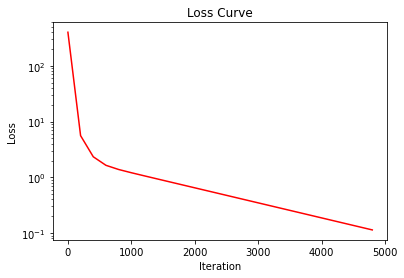


Weights are 
 [[2.09412206]
 [3.12984621]
 [4.21226571]]

Actual Y for Test Data is
 [[15]
 [24]
 [35]
 [27]
 [ 8]]

Predicted Y for Test Data is
 [[14.68]
 [24.1 ]
 [35.58]
 [27.2 ]
 [ 7.34]]

Error is  0.18365722220920705


In [5]:
linear_Obj=linearRegression()

# Training
linear_Obj.Train(X=X,y=y_actual_train,alpha=0.001,loss_iterations=200)
weights=linear_Obj.Get_weights()
print(f"\nWeights are \n {weights}\n")


# Testing
prediction=linear_Obj.Predict(X_test,weights)
formatted_prediction = np.vectorize(lambda x: "{:.2f}".format(x))(prediction)

print(f"Actual Y for Test Data is\n {y_actual_test.reshape(-1,1)}")
print(f"\nPredicted Y for Test Data is\n {formatted_prediction.astype(float)}")
print(f"\nError is  {linear_Obj.cost_function(y_actual_test.reshape(-1,1),prediction)}")


Plot Y-actual and Y-predicted for Test Data

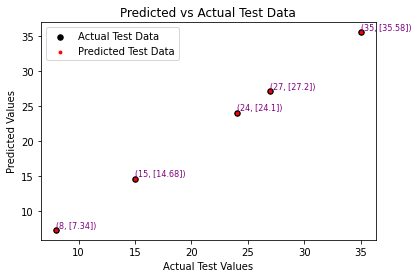

In [6]:
# Plot actual values
plt.scatter(y_actual_test,formatted_prediction.astype(float), label='Actual Test Data', color='black',s=30)

# Plot predicted values
plt.scatter(y_actual_test,formatted_prediction.astype(float), label='Predicted Test Data', color='red',s=8)

for i, (actual, pred) in enumerate(zip(y_actual_test,formatted_prediction.astype(float))):
    plt.text(actual, pred, f'({actual}, {pred})', ha='left', va='bottom', fontsize=8, color='purple')
    

plt.xlabel('Actual Test Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Test Data')
plt.legend()


plt.show()
